# Exploratory Data Analysis & Trends
Analyze patterns and trends in the trade flow data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    '../data/processed/'
    'daily_port_cargo_generation.csv',
    parse_dates=['Record_Date'])

df['Month_Year'] = df[
    'Record_Date'].dt.to_period('M')

print("Shape:", df.shape)
print("Date range:",
      df['Record_Date'].min(),
      "to",
      df['Record_Date'].max())
display(df.head())

Shape: (3291, 12)
Date range: 2023-06-01 00:00:00 to 2026-06-01 00:00:00


,Record_Date,Year,Month,Day,Port_Region,Cargo_Type,Import_Volume_MMT,Export_Volume_MMT,Total_Volume_MMT,Vessel_Arrival_Count,Avg_Berth_Turnaround_Days,Month_Year
0,2023-06-01,2023,6,1,Gujarat Coast (Hazira/Mundra),Container Tonnage,0.085,0.069,0.154,2,1.23,2023-06
1,2023-06-01,2023,6,1,Gujarat Coast (Hazira/Mundra),Dry Bulk (Coal/Minerals),0.044,0.047,0.091,0,0.00,2023-06
2,2023-06-01,2023,6,1,Gujarat Coast (Hazira/Mundra),Liquid Cargo (POL/Crude),0.032,0.034,0.066,1,2.45,2023-06
3,2023-06-02,2023,6,2,Gujarat Coast (Hazira/Mundra),Container Tonnage,0.099,0.081,0.180,2,1.28,2023-06
4,2023-06-02,2023,6,2,Gujarat Coast (Hazira/Mundra),Dry Bulk (Coal/Minerals),0.056,0.061,0.117,1,1.92,2023-06


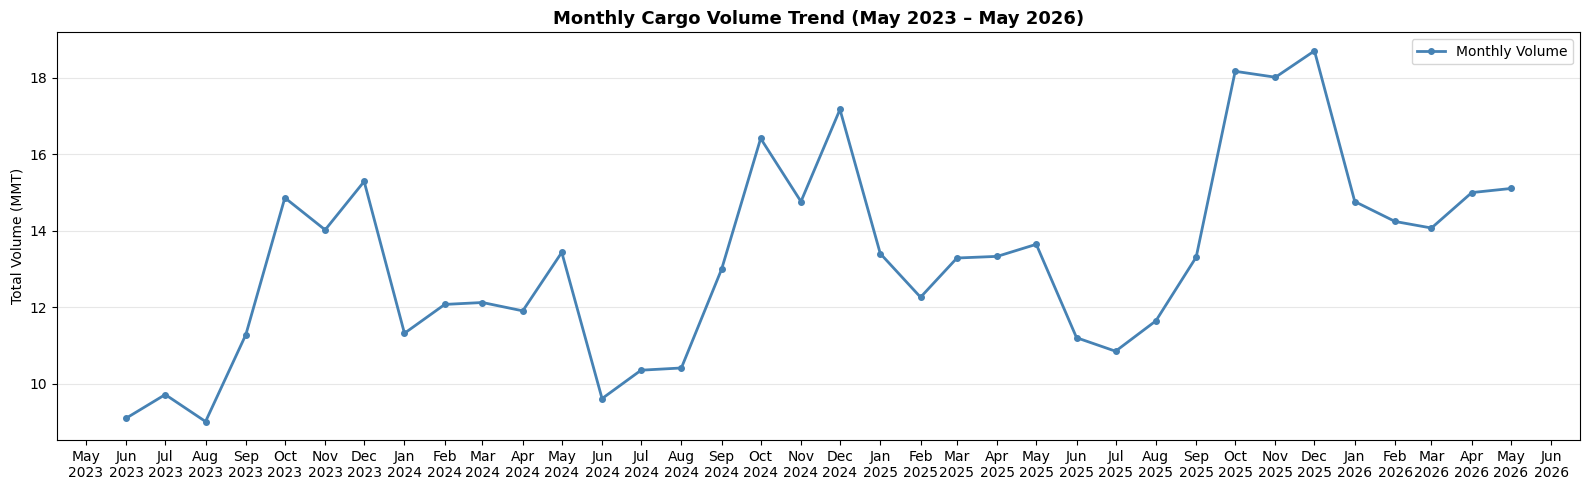

In [6]:
# Filter complete months only
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    '../data/processed/'
    'daily_port_cargo_generation.csv',
    parse_dates=['Record_Date'])

# Remove current partial month
current_month = df[
    'Record_Date'].max().to_period('M')
df_complete = df[
    df['Record_Date'].dt.to_period('M')
    != current_month]

monthly = (df_complete
    .groupby(df_complete[
        'Record_Date'].dt.to_period('M'))
    ['Total_Volume_MMT']
    .sum()
    .reset_index())
monthly.columns = ['Month', 'Volume']
monthly['Month'] = (
    monthly['Month'].dt.to_timestamp())

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly['Month'],
        monthly['Volume'],
        color='steelblue',
        linewidth=2,
        marker='o',
        markersize=4,
        label='Monthly Volume')

# Every month on x-axis
ax.xaxis.set_major_locator(
    mdates.MonthLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b\n%Y'))

ax.set_title(
    'Monthly Cargo Volume Trend '
    '(May 2023 – May 2026)',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Total Volume (MMT)')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(
    '../assets/monthly_trend_fixed.png',
    dpi=150, bbox_inches='tight')
plt.show()

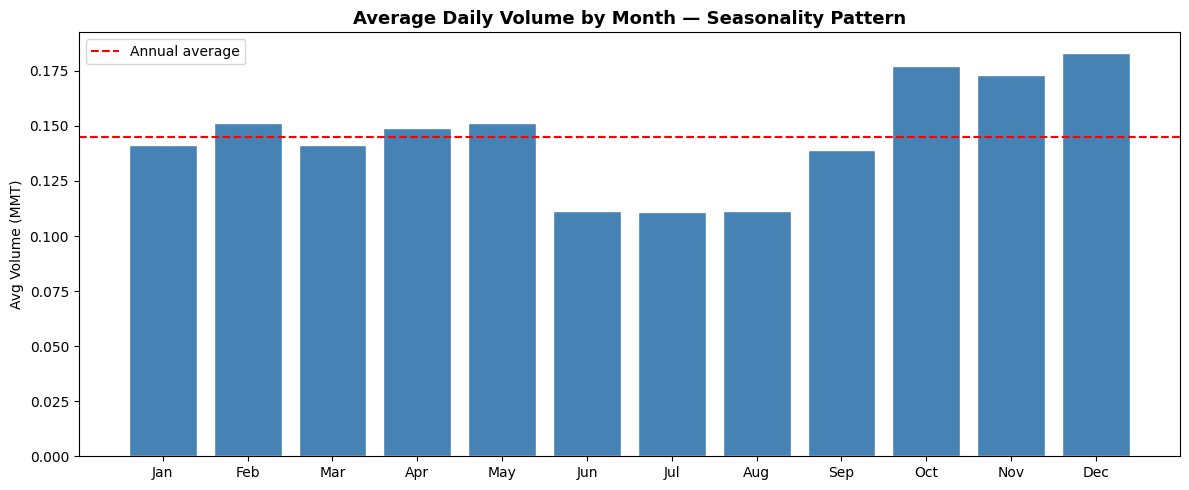

In [3]:
df['month_num'] = df[
    'Record_Date'].dt.month
monthly_avg = (df.groupby('month_num')
    ['Total_Volume_MMT']
    .mean()
    .reset_index())

month_names = ['Jan','Feb','Mar','Apr',
    'May','Jun','Jul','Aug','Sep',
    'Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(
    month_names,
    monthly_avg['Total_Volume_MMT'],
    color='steelblue',
    edgecolor='white')
ax.axhline(
    monthly_avg[
        'Total_Volume_MMT'].mean(),
    color='red', linestyle='--',
    label='Annual average')
ax.set_title(
    'Average Daily Volume by Month'
    ' — Seasonality Pattern',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Volume (MMT)')
ax.legend()
plt.tight_layout()
plt.savefig(
    '../assets/seasonality_pattern.png',
    dpi=150, bbox_inches='tight')
plt.show()

In [4]:
df.to_csv(
    '../data/processed/'
    'clean_cargo_trends.csv',
    index=False)
print("Saved: clean_cargo_trends.csv")
print("Shape:", df.shape)

Saved: clean_cargo_trends.csv
Shape: (3291, 13)


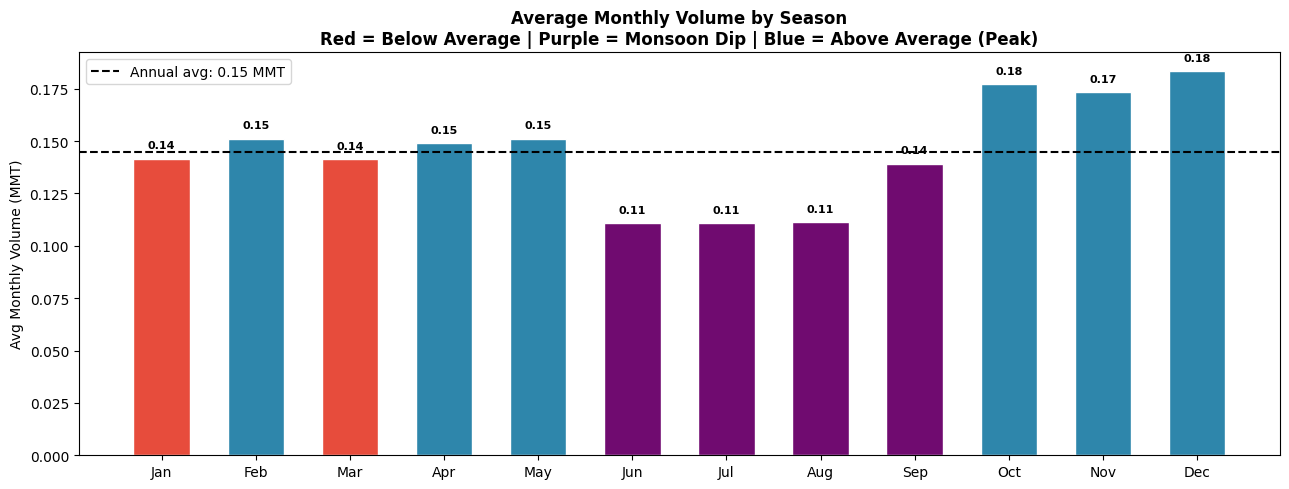

In [10]:


# Assign specific categories including the localized monsoon window
colors = []
mean_volume = monthly_seasonal['avg_monthly_volume'].mean()

for idx, row in monthly_seasonal.iterrows():
    if row['month_name'] in ['Jun', 'Jul', 'Aug', 'Sep']:
        colors.append('#700B70')  # Deep Purple for Monsoon Dip
    elif row['avg_monthly_volume'] < mean_volume:
        colors.append('#E74C3C')  # Red for Below Average
    else:
        colors.append('#2E86AB')  # Blue for Above Average (Peak)

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(
    monthly_seasonal['month_name'],
    monthly_seasonal['avg_monthly_volume'],
    color=colors,
    edgecolor='white',
    width=0.6
)

ax.axhline(
    mean_volume,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f"Annual avg: {mean_volume:.2f} MMT"
)

for bar, val in zip(bars, monthly_seasonal['avg_monthly_volume']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.005,
        f'{val:.2f}',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

# Clean and professional title adjustment
ax.set_title(
    'Average Monthly Volume by Season\n'
    'Red = Below Average | Purple = Monsoon Dip | Blue = Above Average (Peak)',
    fontsize=12, 
    fontweight='bold'
)

ax.set_ylabel('Avg Monthly Volume (MMT)')
ax.legend(loc='upper left')
plt.tight_layout()

plt.savefig(
    '../assets/seasonality_fixed.png',
    dpi=150, 
    bbox_inches='tight'
)
plt.show()

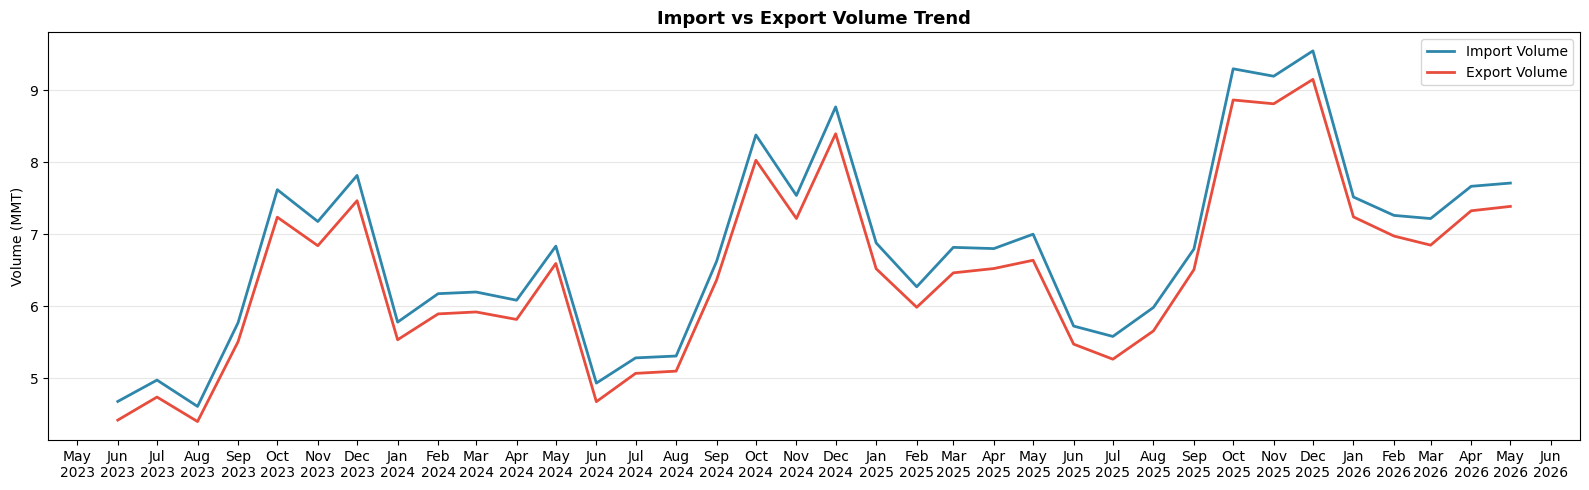

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))

import_monthly = (df_complete
    .groupby(df_complete[
        'Record_Date'].dt.to_period('M'))
    ['Import_Volume_MMT'].sum()
    .reset_index())
export_monthly = (df_complete
    .groupby(df_complete[
        'Record_Date'].dt.to_period('M'))
    ['Export_Volume_MMT'].sum()
    .reset_index())

import_monthly.columns = [
    'Month', 'Import']
export_monthly.columns = [
    'Month', 'Export']
import_monthly['Month'] = (
    import_monthly['Month']
    .dt.to_timestamp())
export_monthly['Month'] = (
    export_monthly['Month']
    .dt.to_timestamp())

ax.plot(import_monthly['Month'],
        import_monthly['Import'],
        color='#2E86AB',
        linewidth=2,
        label='Import Volume')
ax.plot(export_monthly['Month'],
        export_monthly['Export'],
        color='#E74C3C',
        linewidth=2,
        label='Export Volume')

ax.xaxis.set_major_locator(
    mdates.MonthLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b\n%Y'))
ax.set_title(
    'Import vs Export Volume Trend',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Volume (MMT)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../assets/import_export_trend.png',
    dpi=150, bbox_inches='tight')
plt.show()

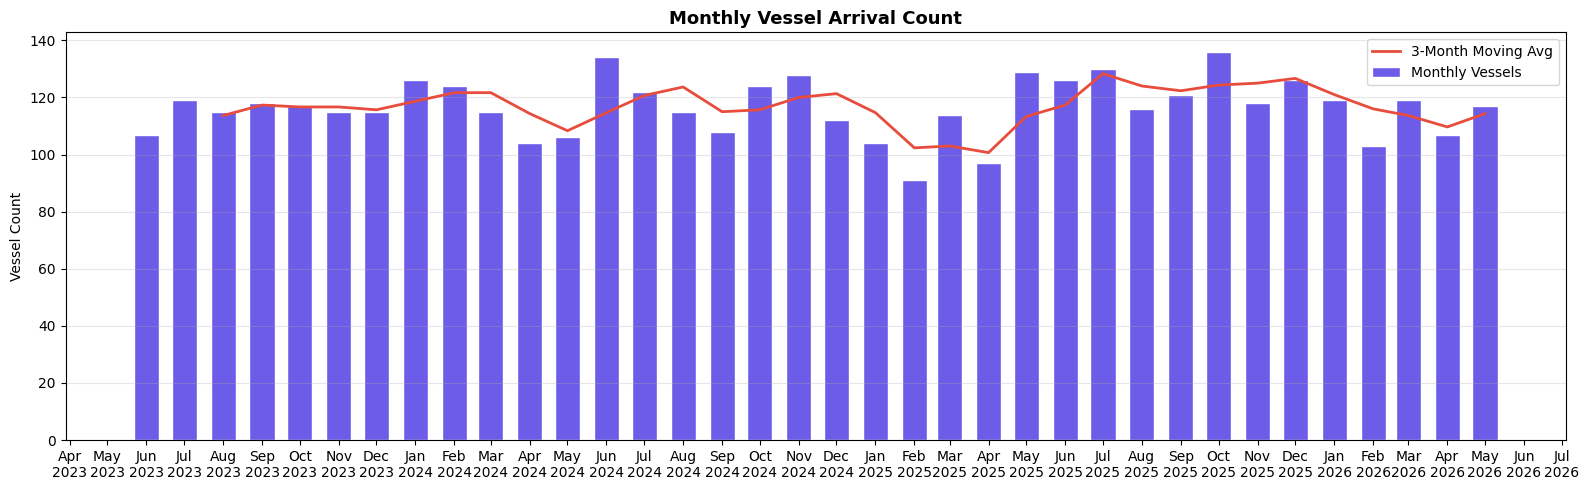

In [9]:
vessel_monthly = (df_complete
    .groupby(df_complete[
        'Record_Date'].dt.to_period('M'))
    ['Vessel_Arrival_Count'].sum()
    .reset_index())
vessel_monthly.columns = [
    'Month', 'Vessels']
vessel_monthly['Month'] = (
    vessel_monthly['Month']
    .dt.to_timestamp())

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(vessel_monthly['Month'],
       vessel_monthly['Vessels'],
       color='#6C5CE7',
       width=20,
       edgecolor='white',
       label='Monthly Vessels')
ax.plot(vessel_monthly['Month'],
        vessel_monthly['Vessels']
        .rolling(3).mean(),
        color='#E74C3C',
        linewidth=2,
        label='3-Month Moving Avg')

ax.xaxis.set_major_locator(
    mdates.MonthLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b\n%Y'))
ax.set_title(
    'Monthly Vessel Arrival Count',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Vessel Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../assets/vessel_arrivals.png',
    dpi=150, bbox_inches='tight')
plt.show()

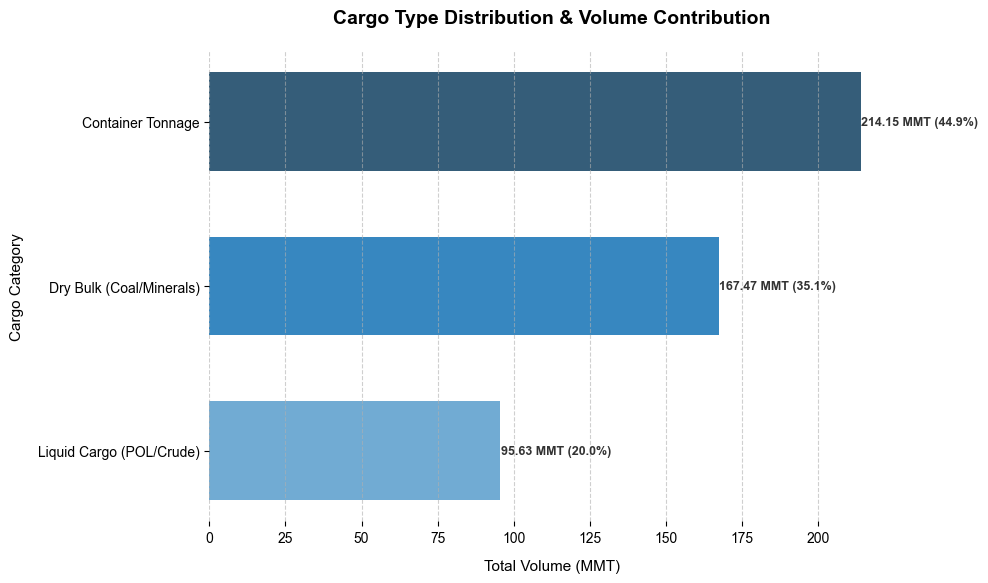

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Aggregate data by Cargo Type using your 'df' variable
cargo_breakdown = (
    df.groupby('Cargo_Type')['Total_Volume_MMT']
    .sum()
    .reset_index()
    .sort_values('Total_Volume_MMT', ascending=True)
)

# Calculate percentage contribution for each category
total_project_volume = cargo_breakdown['Total_Volume_MMT'].sum()
cargo_breakdown['percentage'] = (
    (cargo_breakdown['Total_Volume_MMT'] / total_project_volume) * 100
)

# 2. Plotting Configuration
fig, ax = plt.subplots(figsize=(10, 6))

# Professional, clean layout settings
sns.set_theme(style="whitegrid")
colors = sns.color_palette("Blues_d", n_colors=len(cargo_breakdown))

# Generate horizontal bar chart
bars = ax.barh(
    cargo_breakdown['Cargo_Type'],
    cargo_breakdown['Total_Volume_MMT'],
    color=colors,
    edgecolor='none',
    height=0.6
)

# 3. Add Data Labels (Value and Percentage Contribution)
for bar, val, pct in zip(
    bars, 
    cargo_breakdown['Total_Volume_MMT'], 
    cargo_breakdown['percentage']
):
    ax.text(
        val + 0.05, 
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f} MMT ({pct:.1f}%)',
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

# 4. Professional Formatting Adjustments
ax.set_title(
    'Cargo Type Distribution & Volume Contribution', 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)
ax.set_xlabel('Total Volume (MMT)', fontsize=11, labelpad=10)
ax.set_ylabel('Cargo Category', fontsize=11, labelpad=10)

# Clean boundaries
sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()

# Save the asset cleanly into your assets directory
plt.savefig(
    '../assets/cargo_type_breakdown.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()